In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preparations and data loading

In [ ]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample

In [ ]:
# Import the data: Camelyon17 from WILDS benchmark
from wilds import get_dataset

dataset = get_dataset(dataset="camelyon17", download=True,
                      root_dir=str(WORK_ROOT))

In [ ]:
# Load Dinov2 checkpoint, split and wrap data
from wilds.common.data_loaders import get_train_loader, get_eval_loader

class WILDSWrapper(Dataset):
    def __init__(self, wilds_subset, transform):
        self.subset = wilds_subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y, metadata = self.subset[idx]
        # x is already a PIL image or tensor depending on version
        if self.transform:
            x = self.transform(x)
        return x, y.item()

# Load DINOv2 ViT-B/14
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model.eval().cuda()

transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

# Source: hospitals 0-3 (train)
# Target: hospital 4 (test) — the OOD split
train_subset = dataset.get_subset("train", transform=None)
val_subset   = dataset.get_subset("id_val", transform=None)   # source val
test_subset  = dataset.get_subset("test", transform=None)     # target test

train_data = WILDSWrapper(train_subset, transform=transform)
val_data   = WILDSWrapper(val_subset,   transform=transform)
test_data  = WILDSWrapper(test_subset,  transform=transform)

In [ ]:
# Compute representations from Dinov2 (dimension 758)
@torch.no_grad()
def extract_features(dataset, batch_size=512, desc="Extracting"):
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=4, pin_memory=True)
    all_features, all_labels = [], []

    for images, labels in tqdm(loader, desc=desc, unit="batch"):
        images = images.cuda()
        features = model(images)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)

X_train, y_train = extract_features(train_data, desc="Camelyon train")
X_val,   y_val   = extract_features(val_data,   desc="Camelyon id_val")
X_test,  y_test  = extract_features(test_data,  desc="Camelyon test")


D2 size: 100 per class (200 total for binary)
  Seed 10/100 — naive=0.6486  pseudo=0.6359  oracle=0.6083
  Seed 20/100 — naive=0.6900  pseudo=0.6433  oracle=0.6246
  Seed 30/100 — naive=0.6826  pseudo=0.6435  oracle=0.6212
  Seed 40/100 — naive=0.6777  pseudo=0.6473  oracle=0.6164
  Seed 50/100 — naive=0.6789  pseudo=0.6464  oracle=0.6189
  Seed 60/100 — naive=0.6832  pseudo=0.6492  oracle=0.6194
  Seed 70/100 — naive=0.6873  pseudo=0.6483  oracle=0.6210
  Seed 80/100 — naive=0.6837  pseudo=0.6458  oracle=0.6205
  Seed 90/100 — naive=0.6818  pseudo=0.6443  oracle=0.6201
  Seed 100/100 — naive=0.6821  pseudo=0.6451  oracle=0.6211

D2 size: 200 per class (400 total for binary)
  Seed 10/100 — naive=0.6509  pseudo=0.6192  oracle=0.6083
  Seed 20/100 — naive=0.6853  pseudo=0.6323  oracle=0.6246
  Seed 30/100 — naive=0.6751  pseudo=0.6304  oracle=0.6212
  Seed 40/100 — naive=0.6696  pseudo=0.6329  oracle=0.6164
  Seed 50/100 — naive=0.6748  pseudo=0.6342  oracle=0.6189
  Seed 60/100 — naiv

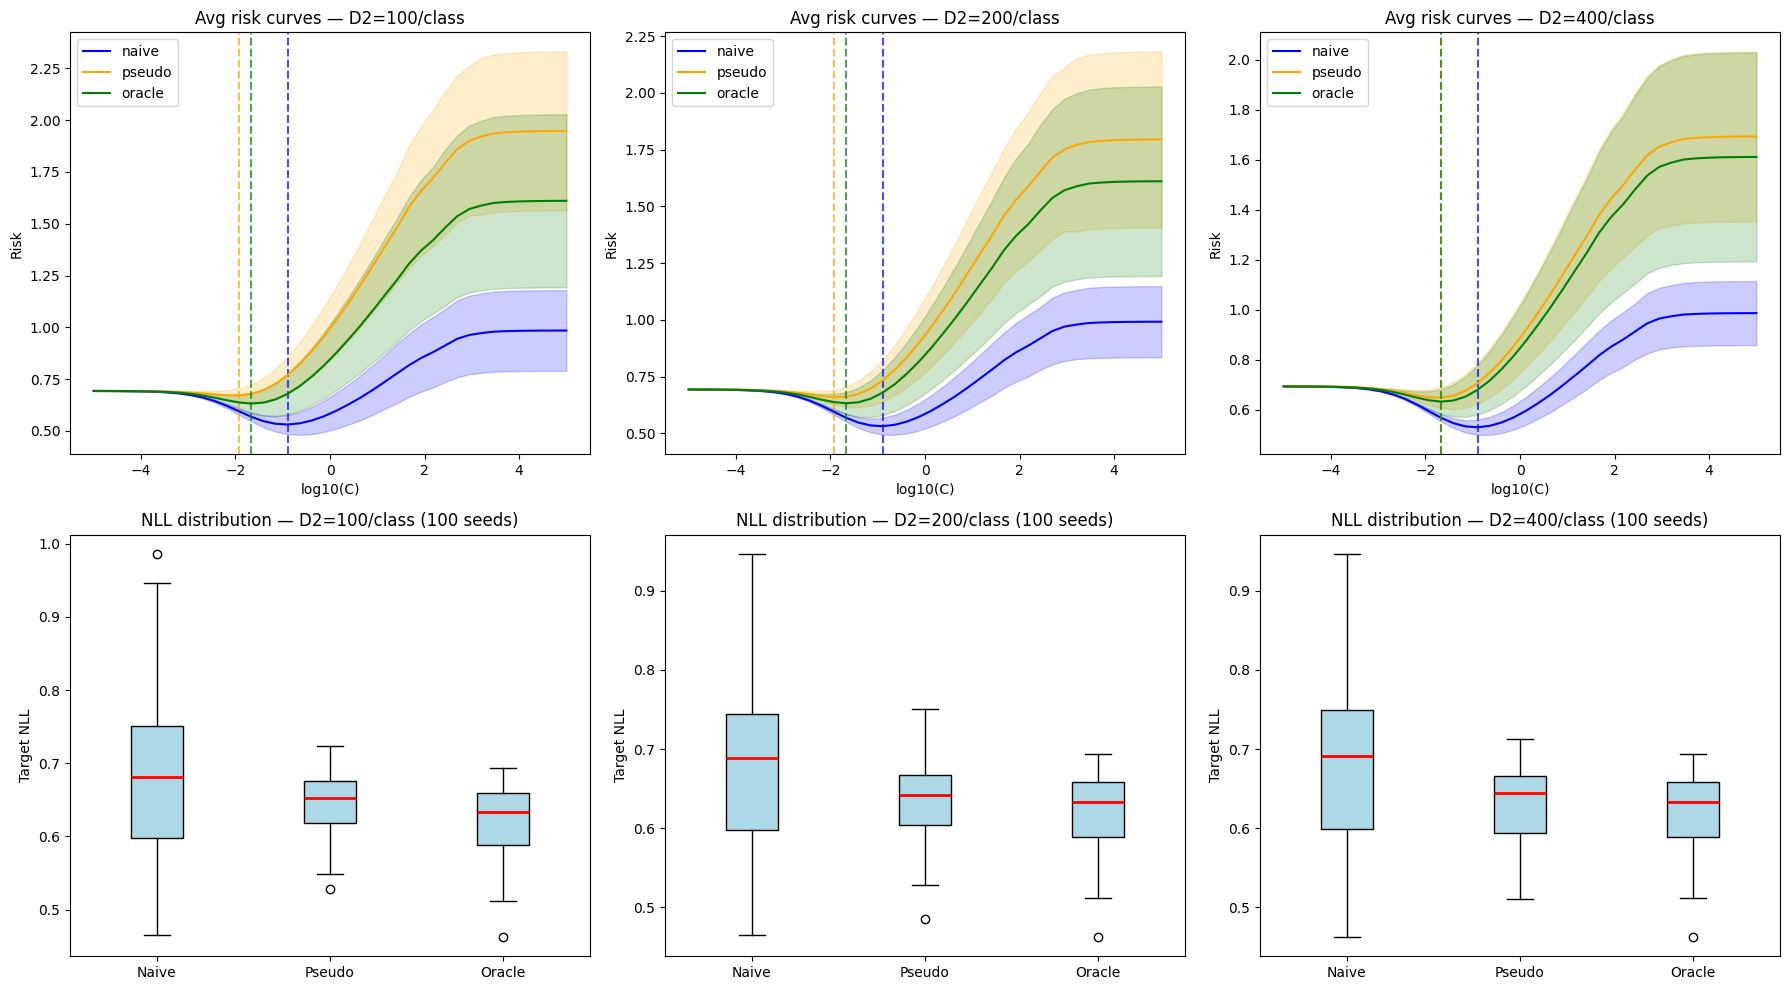

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
N_D1_PER_CLASS = 50
N_SEEDS        = 100
C_GRID         = np.logspace(-5, 5, 40)
D2_SIZES       = [100, 200, 400]   # sensitivity analysis on imputer size

# ── Preprocessing ─────────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pca       = PCA(n_components=256, whiten=True)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

# ── Core function ─────────────────────────────────────────────────────────────
def run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                         C_grid, n_d2_per_class, seed=0):
    rng     = np.random.default_rng(seed)
    classes = np.unique(y_train)
    D1_idx, D2_idx = [], []

    for c in classes:
        idx_c = np.where(y_train == c)[0]
        idx_c = rng.permutation(idx_c)
        D1_idx.extend(idx_c[:N_D1_PER_CLASS])
        D2_idx.extend(idx_c[N_D1_PER_CLASS:N_D1_PER_CLASS + n_d2_per_class])

    D1_idx = np.array(D1_idx)
    D2_idx = np.array(D2_idx)
    X1, y1 = X_train_p[D1_idx], y_train[D1_idx]
    X2, y2 = X_train_p[D2_idx], y_train[D2_idx]

    # Imputer on D2 — largest C in grid
    imputer = LogisticRegression(C=C_grid.max(), penalty="l2",
                                  solver="lbfgs", max_iter=2000)
    imputer.fit(X2, y2)
    pseudo_labels = imputer.predict_proba(X_test_p)

    # Sweep candidates on D1
    pseudo_risks, naive_risks, oracle_risks = [], [], []

    for C in C_grid:
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)

        proba_target = clf.predict_proba(X_test_p)
        pseudo_risk  = -np.mean(np.sum(pseudo_labels *
                                np.log(proba_target + 1e-10), axis=1))
        pseudo_risks.append(pseudo_risk)
        naive_risks.append(log_loss(y2,     clf.predict_proba(X2)))
        oracle_risks.append(log_loss(y_test, clf.predict_proba(X_test_p)))

    C_pseudo = C_grid[np.argmin(pseudo_risks)]
    C_naive  = C_grid[np.argmin(naive_risks)]
    C_oracle = C_grid[np.argmin(oracle_risks)]

    results = {}
    for name, C_sel in [("pseudo", C_pseudo),
                         ("naive",  C_naive),
                         ("oracle", C_oracle)]:
        clf = LogisticRegression(C=C_sel, penalty="l2", solver="lbfgs",
                                  max_iter=2000)
        clf.fit(X1, y1)
        proba = clf.predict_proba(X_test_p)
        pred  = clf.predict(X_test_p)
        results[name] = {
            "C_selected": C_sel,
            "nll":        log_loss(y_test, proba),
            "accuracy":   accuracy_score(y_test, pred),
        }

    # Also store full risk curves for averaging
    results["_curves"] = {
        "pseudo": pseudo_risks,
        "naive":  naive_risks,
        "oracle": oracle_risks,
    }

    return results

# ── Run over seeds and D2 sizes ───────────────────────────────────────────────
# Structure: results_by_d2[n_d2] = {method: [nll, ...], ...}
results_by_d2 = {}

for n_d2 in D2_SIZES:
    print(f"\n{'='*60}")
    print(f"D2 size: {n_d2} per class ({n_d2 * 2} total for binary)")
    print(f"{'='*60}")

    all_nll      = {"pseudo": [], "naive": [], "oracle": []}
    all_acc      = {"pseudo": [], "naive": [], "oracle": []}
    all_C        = {"pseudo": [], "naive": [], "oracle": []}
    all_curves   = {"pseudo": [], "naive": [], "oracle": []}

    for seed in range(N_SEEDS):
        res = run_pseudo_labeling(X_train_p, y_train, X_test_p, y_test,
                                   C_grid=C_GRID,
                                   n_d2_per_class=n_d2,
                                   seed=seed)
        for method in ["pseudo", "naive", "oracle"]:
            all_nll[method].append(res[method]["nll"])
            all_acc[method].append(res[method]["accuracy"])
            all_C[method].append(res[method]["C_selected"])
            all_curves[method].append(res["_curves"][method])

        if (seed + 1) % 10 == 0:
            print(f"  Seed {seed+1}/{N_SEEDS} — "
                  f"naive={np.mean(all_nll['naive']):.4f}  "
                  f"pseudo={np.mean(all_nll['pseudo']):.4f}  "
                  f"oracle={np.mean(all_nll['oracle']):.4f}")

    results_by_d2[n_d2] = {
        "nll":    all_nll,
        "acc":    all_acc,
        "C":      all_C,
        "curves": all_curves,
    }

# ── Report table ──────────────────────────────────────────────────────────────
for n_d2 in D2_SIZES:
    res = results_by_d2[n_d2]
    print(f"\nD2 = {n_d2} per class — NLL")
    print(f"{'Method':<10} {'Mean':>8} {'Std':>8} {'95% CI':>20} {'Mean C':>10}")
    print("-" * 62)
    for method in ["naive", "pseudo", "oracle"]:
        nlls = np.array(res["nll"][method])
        Cs   = np.array(res["C"][method])
        mean = nlls.mean()
        std  = nlls.std()
        ci   = 1.96 * std / np.sqrt(len(nlls))
        print(f"{method:<10} {mean:>8.4f} {std:>8.4f} "
              f"[{mean-ci:.4f}, {mean+ci:.4f}]  {Cs.mean():>10.4f}")

    print(f"\nD2 = {n_d2} per class — Accuracy")
    print(f"{'Method':<10} {'Mean':>8} {'Std':>8} {'95% CI':>20}")
    print("-" * 50)
    for method in ["naive", "pseudo", "oracle"]:
        accs = np.array(res["acc"][method])
        mean = accs.mean()
        std  = accs.std()
        ci   = 1.96 * std / np.sqrt(len(accs))
        print(f"{method:<10} {mean:>8.4f} {std:>8.4f} [{mean-ci:.4f}, {mean+ci:.4f}]")

# ── Sensitivity summary ───────────────────────────────────────────────────────
print("\nSensitivity to D2 size — Mean NLL")
print(f"{'D2/class':<12}", end="")
for method in ["naive", "pseudo", "oracle"]:
    print(f"{method:>14}", end="")
print()
print("-" * 54)
for n_d2 in D2_SIZES:
    print(f"{n_d2:<12}", end="")
    for method in ["naive", "pseudo", "oracle"]:
        nlls = np.array(results_by_d2[n_d2]["nll"][method])
        print(f"{nlls.mean():>14.4f}", end="")
    print()

# ── Save results ─────────────────────────────────────────────────────────────────────
import pickle

with open(DRIVE_ROOT / "camelyon17_full_results.pkl", "wb") as f:
    pickle.dump({
        "results_by_d2": results_by_d2,
        "config": {
            "n_d1_per_class": N_D1_PER_CLASS,
            "n_seeds":        N_SEEDS,
            "C_grid":         C_GRID,
            "d2_sizes":       D2_SIZES,
        }
    }, f)

print("Saved to", DRIVE_ROOT / "camelyon17_full_results.pkl")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, n_d2 in enumerate(D2_SIZES):
    res    = results_by_d2[n_d2]
    log_C  = np.log10(C_GRID)
    colors = {"naive": "blue", "pseudo": "orange", "oracle": "green"}

    # Top row: average risk curves
    ax = axes[0, col]
    for method in ["naive", "pseudo", "oracle"]:
        curves = np.array(res["curves"][method])
        mean   = curves.mean(axis=0)
        std    = curves.std(axis=0)
        ax.plot(log_C, mean, color=colors[method], label=method)
        ax.fill_between(log_C, mean - std, mean + std,
                         alpha=0.2, color=colors[method])
        # Mark selected C
        opt_idx = np.argmin(mean)
        ax.axvline(log_C[opt_idx], color=colors[method],
                   linestyle="--", alpha=0.7)
    ax.set_xlabel("log10(C)")
    ax.set_ylabel("Risk")
    ax.set_title(f"Avg risk curves — D2={n_d2}/class")
    ax.legend()

    # Bottom row: NLL boxplots
    ax = axes[1, col]
    ax.boxplot([res["nll"]["naive"],
                res["nll"]["pseudo"],
                res["nll"]["oracle"]],
                labels=["Naive", "Pseudo", "Oracle"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    ax.set_ylabel("Target NLL")
    ax.set_title(f"NLL distribution — D2={n_d2}/class ({N_SEEDS} seeds)")

plt.tight_layout()
plt.savefig(DRIVE_ROOT / "camelyon17_results.png", dpi=150, bbox_inches="tight")
plt.show()